Loading data...
Target variable distribution (Delay):
Delay
1    63.01
0    36.99
Name: proportion, dtype: float64


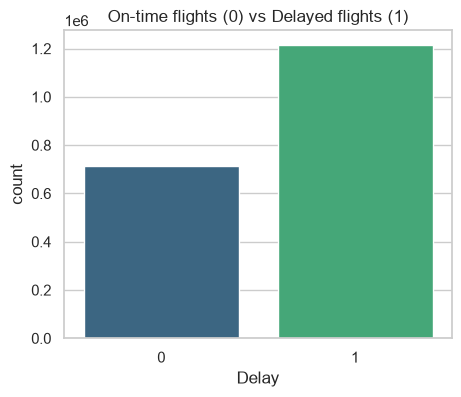

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# 1. Load data
print("Loading data...")
df = pd.read_csv('../data/raw/DelayedFlights.csv')

# 2. Remove rows where ArrDelay is missing (only 0.43%, so it does not affect the analysis)
df = df.dropna(subset=['ArrDelay'])

# 3. Create the target variable: 1 (Delay > 15 min) and 0 (On time)
# In the aviation industry, <= 15 min is considered "On Time"
df['Delay'] = (df['ArrDelay'] > 15).astype(int)

# 4. Check whether the data is imbalanced
print("Target variable distribution (Delay):")
dist = df['Delay'].value_counts(normalize=True) * 100
print(round(dist, 2))

plt.figure(figsize=(5, 4))
sns.countplot(x='Delay', data=df, palette='viridis')
plt.title('On-time flights (0) vs Delayed flights (1)')
plt.show()

In [14]:
# Features known weeks before the flight
features = [
    'Month', 'DayOfWeek', 'UniqueCarrier',
    'Origin', 'Dest', 'Distance', 'CRSDepTime'
]
target = 'Delay'

# Create a new DataFrame with only the variables available to the model
df_model = df[features + [target]].copy()

print("Final dataset shape for the model:")
print(df_model.head())
print("\nMissing values check in predictor variables:")
print(df_model.isnull().sum())

Final dataset shape for the model:
   Month  DayOfWeek UniqueCarrier Origin Dest  Distance  CRSDepTime  Delay
0      1          4            WN    IAD  TPA       810        1955      0
1      1          4            WN    IAD  TPA       810         735      0
2      1          4            WN    IND  BWI       515         620      0
3      1          4            WN    IND  BWI       515        1755      1
4      1          4            WN    IND  JAX       688        1915      0

Missing values check in predictor variables:
Month            0
DayOfWeek        0
UniqueCarrier    0
Origin           0
Dest             0
Distance         0
CRSDepTime       0
Delay            0
dtype: int64


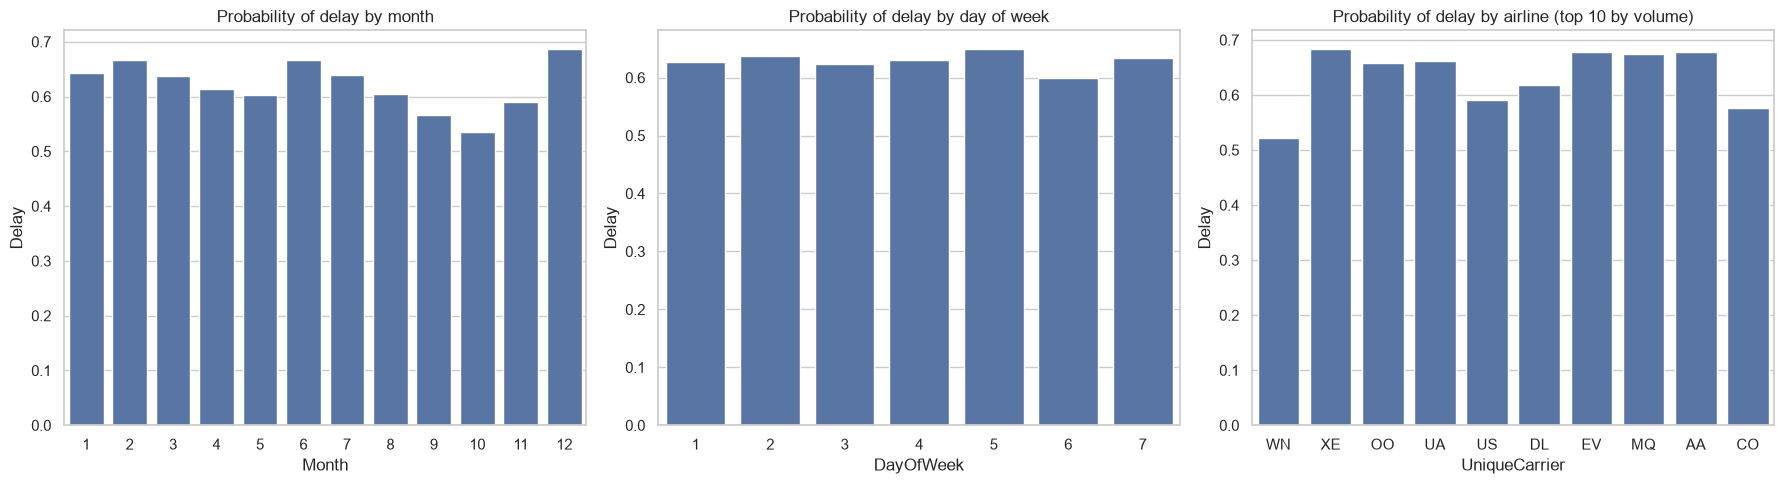

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Delays by month
sns.barplot(x='Month', y='Delay', data=df_model, ax=axes[0], ci=None)
axes[0].set_title('Probability of delay by month')

# Delays by day of week
sns.barplot(x='DayOfWeek', y='Delay', data=df_model, ax=axes[1], ci=None)
axes[1].set_title('Probability of delay by day of week')

# Top 10 airlines by flight volume
top_carriers = df_model['UniqueCarrier'].value_counts().head(10).index
df_top_carriers = df_model[df_model['UniqueCarrier'].isin(top_carriers)]

sns.barplot(x='UniqueCarrier', y='Delay', data=df_top_carriers, ax=axes[2], ci=None)
axes[2].set_title('Probability of delay by airline (top 10 by volume)')

plt.tight_layout()
plt.show()

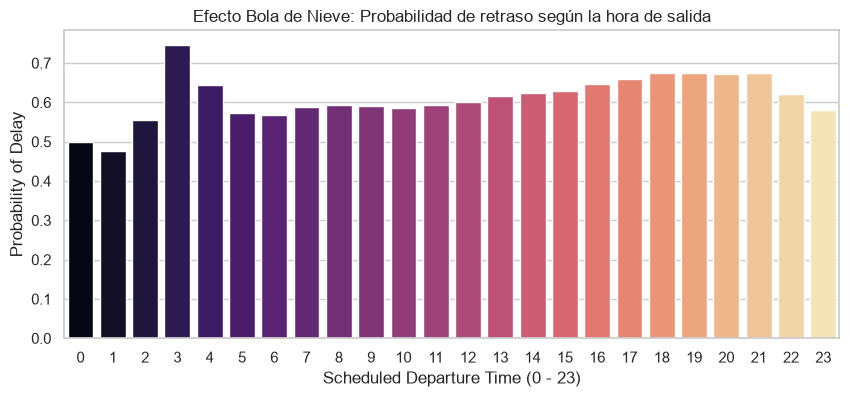

In [16]:
# Extract only hour
df_model['DepHour'] = df_model['CRSDepTime'] // 100

plt.figure(figsize=(10, 4))
sns.barplot(x='DepHour', y='Delay', data=df_model, ci=None, palette='magma')
plt.title('Efecto Bola de Nieve: Probabilidad de retraso según la hora de salida')
plt.xlabel('Scheduled Departure Time (0 - 23)')
plt.ylabel('Probability of Delay')
plt.show()

In [17]:
# 1. Ensure we have the necessary temporal grouping columns
df_model['Year'] = df['Year']
df_model['DayofMonth'] = df['DayofMonth']
df_model['CRSArrTime'] = df['CRSArrTime']

# 2. Extract hours
df_model['DepHour'] = df_model['CRSDepTime'] // 100
df_model['ArrHour'] = df_model['CRSArrTime'] // 100

print("Calculating full runway congestion for the Departure Airport...")

# --- STEP A: Count Departures from the Origin Airport ---
# Group by Date, Origin Airport, and Departure Hour
departures_count = df_model.groupby(
    ['Year', 'Month', 'DayofMonth', 'Origin', 'DepHour']
).size().reset_index(name='Concurrent_Departures')


# --- STEP B: Count Arrivals to the Origin Airport ---
# We group by Date, DESTINATION (which must match the Origin we are analyzing), and Arrival Hour
arrivals_count = df_model.groupby(
    ['Year', 'Month', 'DayofMonth', 'Dest', 'ArrHour']
).size().reset_index(name='Concurrent_Arrivals')

# Rename columns so they match the Origin's timeframe when we merge them back
arrivals_count = arrivals_count.rename(columns={
    'Dest': 'Origin', 
    'ArrHour': 'DepHour'
})


# --- STEP C: Merge both counts back into the main DataFrame ---

# Merge the departures count
df_model = df_model.merge(
    departures_count, 
    on=['Year', 'Month', 'DayofMonth', 'Origin', 'DepHour'], 
    how='left'
)

# Merge the arrivals count
df_model = df_model.merge(
    arrivals_count, 
    on=['Year', 'Month', 'DayofMonth', 'Origin', 'DepHour'], 
    how='left'
)

# Fill NaNs with 0 (e.g., hours where there are departures but 0 arrivals)
df_model['Concurrent_Arrivals'] = df_model['Concurrent_Arrivals'].fillna(0).astype(int)

# Create the ultimate feature: Total Runway Congestion
df_model['Total_Origin_Congestion'] = df_model['Concurrent_Departures'] + df_model['Concurrent_Arrivals']

# --- Cleanup ---
# We can drop the temporary columns to keep our dataset clean
df_model = df_model.drop(columns=['Year', 'DayofMonth', 'CRSArrTime', 'ArrHour'])

# Let's inspect the results for a high-traffic airport like ATL or ORD
cols_to_show = ['Origin', 'DepHour', 'Concurrent_Departures', 'Concurrent_Arrivals', 'Total_Origin_Congestion', 'Delay']
print("\nSample showing the runway congestion metrics:")
print(df_model.query("Origin == 'ATL'")[cols_to_show].sample(10, random_state=42))

Calculating full runway congestion for the Departure Airport...

Sample showing the runway congestion metrics:
        Origin  DepHour  Concurrent_Departures  Concurrent_Arrivals  \
721633     ATL       14                     73                   67   
1480600    ATL       20                     21                   10   
1504906    ATL       18                     24                   15   
570805     ATL       13                     38                   34   
1621143    ATL       15                     37                   37   
1832492    ATL       17                     33                   42   
1926211    ATL       14                     28                   23   
1297978    ATL       11                     36                   23   
481635     ATL       12                     15                   15   
721975     ATL       12                     72                   63   

         Total_Origin_Congestion  Delay  
721633                       140      1  
1480600                

Pearson Correlation Coefficient: 0.1173



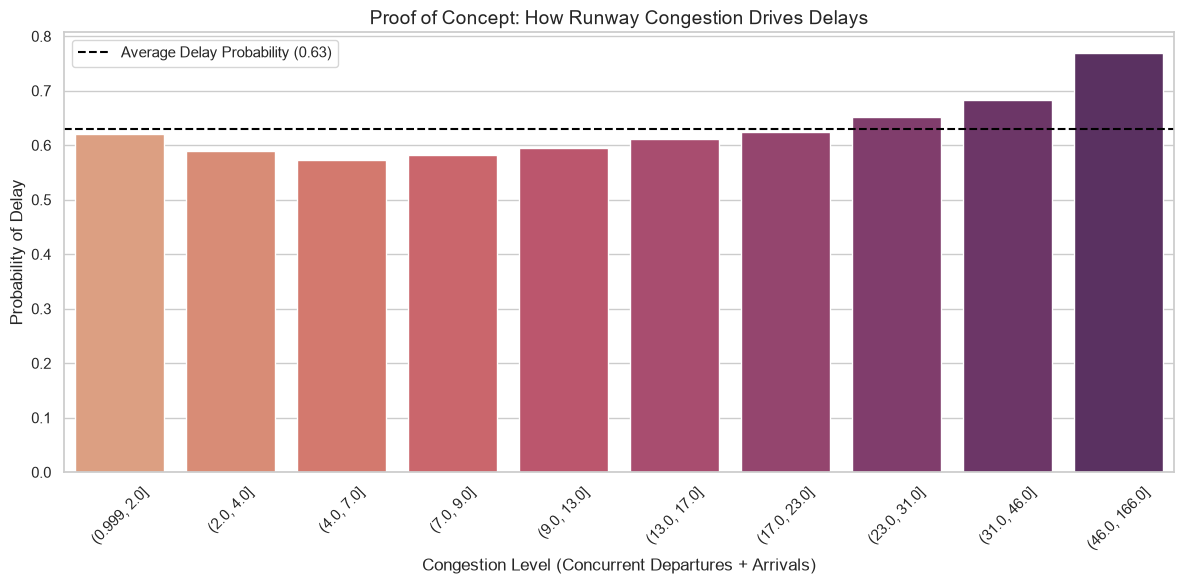

In [18]:
import numpy as np

# 1. The Mathematical Correlation (Pearson)
# A positive number means higher congestion = higher chance of delay
corr = df_model[['Total_Origin_Congestion', 'Delay']].corr().iloc[0, 1]
print(f"Pearson Correlation Coefficient: {corr:.4f}\n")

# 2. The Visual Proof (Binning)
# We divide the congestion feature into 10 equal-sized buckets (deciles) 
# to see if the delay probability increases as the bucket gets more crowded.
df_model['Congestion_Bucket'] = pd.qcut(
    df_model['Total_Origin_Congestion'], 
    q=10, 
    duplicates='drop'
)

# 3. Plotting the results
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Congestion_Bucket', 
    y='Delay', 
    data=df_model, 
    palette='flare', 
    errorbar=None
)

plt.title('Proof of Concept: How Runway Congestion Drives Delays', fontsize=14)
plt.xlabel('Congestion Level (Concurrent Departures + Arrivals)', fontsize=12)
plt.ylabel('Probability of Delay', fontsize=12)
plt.xticks(rotation=45)

# Add a horizontal line representing the baseline average delay of the whole dataset
baseline_delay = df_model['Delay'].mean()
plt.axhline(baseline_delay, color='black', linestyle='--', label=f'Average Delay Probability ({baseline_delay:.2f})')
plt.legend()

plt.tight_layout()
plt.show()

# Clean up the temporary binning column
df_model = df_model.drop(columns=['Congestion_Bucket'])